<p align="center">
  <img src="https://raw.githubusercontent.com/paulmunozpauta/Hidrology_Course/main/Static/Imgs/UdeC_color_horizontal.jpg" width="500">
</p>
<p align="center"><b style="font-size:28px;">Facultad de Ingeniería Agrícola</b></p>
<p align="center"><b style="font-size:28px;">Curso de Hidrología</b></p>
<hr>
<p align="center"><b style="font-size:28px;">Contacto</b></p>
<p align="center">
  paulmunoz@udec.cl<br>
  https://paulmunoz.com
</p>

# Precipitación

## Objetivo

Procesar datos pluviométricos de una estación real en Chile.


## Clonar el repositorio desde GitHub

In [76]:
# Clonar el repositorio desde GitHub
!git clone -- https://github.com/paulmunozpauta/Hidrology_Course

Cloning into 'Hidrology_Course'...
remote: Enumerating objects: 139, done.
remote: Counting objects: 100% (101/101), done.
remote: Compressing objects: 100% (90/90), done.
remote: Total 139 (delta 41), reused 39 (delta 9), pack-reused 38 (from 1)
Receiving objects: 100% (139/139), 63.92 MiB | 18.21 MiB/s, done.
Resolving deltas: 100% (47/47), done.


Después de ejecutar la celda anterior, se crea una carpeta en nuestro entorno llamada:

**Hidrology_Course**

Esta carpeta contiene todos los archivos del curso.

Ahora debemos entrar a esa carpeta para trabajar con los datos.

# Entrar a la carpeta del repositorio





In [77]:
# Entrar a la carpeta del repositorio
%cd Hidrology_Course
!ls

/content/Hidrology_Course/Hidrology_Course
01_Delimitacion_cuenca.ipynb	   03_Precipitación.ipynb  README.md
02_Probabilidad_estadística.ipynb  Data			   Static


##Instalación e importación de librerías


Librerías principales:
pandas
numpy
matplotlib

In [78]:
# Instalar librerías necesarias
!pip -q install pandas

In [79]:
#Importar librerías
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Lectura  de datos hidrometerológicos

Los datos a usar están disponibles de forma libre en: https://explorador.cr2.cl/

Vamos a usar los datos de la estación Puerto Montt de la Dirección General de Aguas de Chile (10425001)

In [80]:
# ruta relativa del archivo en el repositorio
archivo = "Data/Precipitación/PuertoMontt_DGA_10425001.xlsx"
# leer el archivo Excel original de la DGA
PMontt = pd.read_excel(archivo)
PMontt

,agno,mes,dia,valor
0,1973,2,1,0.0
1,1973,2,2,0.0
2,1973,2,3,0.0
3,1973,2,4,0.0
4,1973,2,5,0.0
...,...,...,...,...
17477,2025,4,22,0.2
17478,2025,4,23,0.2
17479,2025,4,24,2.3
17480,2025,4,25,3.7


# Preprocesamiento (preparación) de datos para los análisis

Los datos diarios de esta estación están separados en columnas por "agno", "mes", "día" y "valor".

Vamos a generar una serie (dataframe) ordenada cronológicamente a través de la fecha disponible

In [81]:
# limpiar nombres de columnas
PMontt.columns = PMontt.columns.str.strip().str.lower()

# renombrar por seguridad si vienen con espacios o acentos raros
PMontt = PMontt.rename(columns={
    "agno": "anio",
    "año": "anio",
    "mes": "mes",
    "dia": "dia",
    "valor": "precipitacion_diaria_mm"
})

# convertir columnas a numéricas
for col in ["anio", "mes", "dia", "precipitacion_diaria_mm"]:
    PMontt[col] = pd.to_numeric(PMontt[col], errors="coerce")

# eliminar filas con datos faltantes en columnas clave
PMontt = PMontt.dropna(subset=["anio", "mes", "dia", "precipitacion_diaria_mm"])

# convertir año, mes y día a enteros
PMontt["anio"] = PMontt["anio"].astype(int)
PMontt["mes"] = PMontt["mes"].astype(int)
PMontt["dia"] = PMontt["dia"].astype(int)

# crear columna fecha
PMontt["fecha"] = pd.to_datetime(
    dict(year=PMontt["anio"], month=PMontt["mes"], day=PMontt["dia"]),
    errors="coerce"
)

# eliminar fechas inválidas
PMontt = PMontt.dropna(subset=["fecha"])

# dejar solo la serie temporal final
PMontt = PMontt[["fecha", "precipitacion_diaria_mm"]].copy()

# ordenar por fecha
PMontt = PMontt.sort_values("fecha").reset_index(drop=True)

# opcional: usar fecha como índice
PMontt = PMontt.set_index("fecha")

# mostrar la serie
PMontt


,precipitacion_diaria_mm
fecha,
1973-02-01,0.0
1973-02-02,0.0
1973-02-03,0.0
1973-02-04,0.0
1973-02-05,0.0
...,...
2025-04-22,0.2
2025-04-23,0.2
2025-04-24,2.3


## Figura de de precipitación diaria



Graficar esta serie preprocesada mediante barras, ya que la precipitación es una acumulación en cada día

<Figure size 1200x500 with 0 Axes>

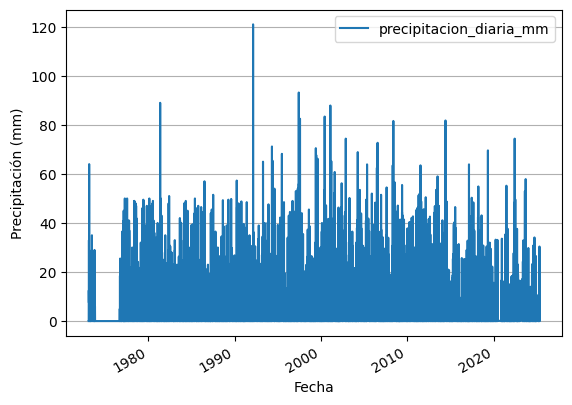

In [82]:
plt.figure(figsize=(12,5))
PMontt.plot()#no lo hacemos como barras por la carga computacional
plt.xlabel("Fecha")
plt.ylabel("Precipitación (mm)")
plt.grid(axis="y")

plt.show()


<Figure size 1500x600 with 0 Axes>

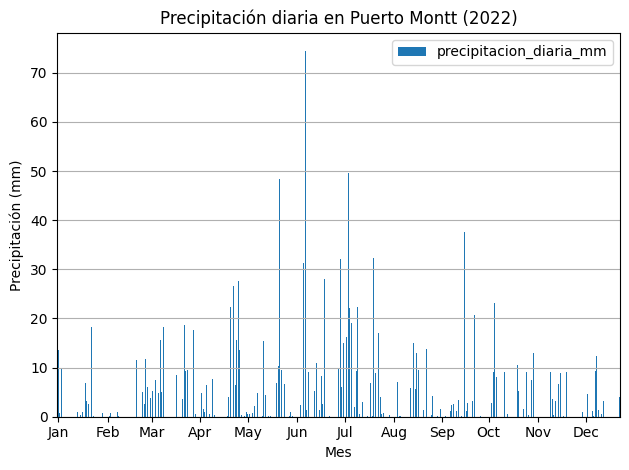

In [83]:

plt.figure(figsize=(15,6))
data_to_plot = PMontt.loc["2022"]
ax = data_to_plot.plot(kind="bar")
# Etiquetas
plt.xlabel("Mes")
plt.ylabel("Precipitación (mm)")
plt.title("Precipitación diaria en Puerto Montt (2022)")
# Mostrar solo un label por mes
dates = data_to_plot.index
month_positions = [i for i, d in enumerate(dates) if d.day == 1]
month_labels = [d.strftime('%b') for d in dates if d.day == 1]  # Ene, Feb, Mar...
ax.set_xticks(month_positions)
ax.set_xticklabels(month_labels, rotation=0)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

<Figure size 1500x600 with 0 Axes>

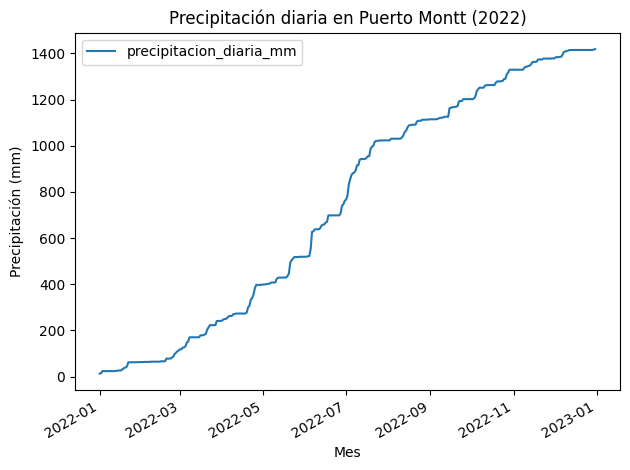

In [84]:
plt.figure(figsize=(15,6))
data_to_plot = PMontt.loc["2022"].cumsum()
ax = data_to_plot.plot()
# Etiquetas
plt.xlabel("Mes")
plt.ylabel("Precipitación (mm)")
plt.title("Precipitación diaria en Puerto Montt (2022)")
plt.tight_layout()
plt.show()

Vamos a rellenar los primeros 15 días, es decir del 1 al 15 de junio de 2020

In [85]:
# Reemplazar con NaN desde el 1 al 15 de julio de 2022
PMontt.loc["2022-07-01":"2022-07-15"] = np.nan

<Figure size 1500x600 with 0 Axes>

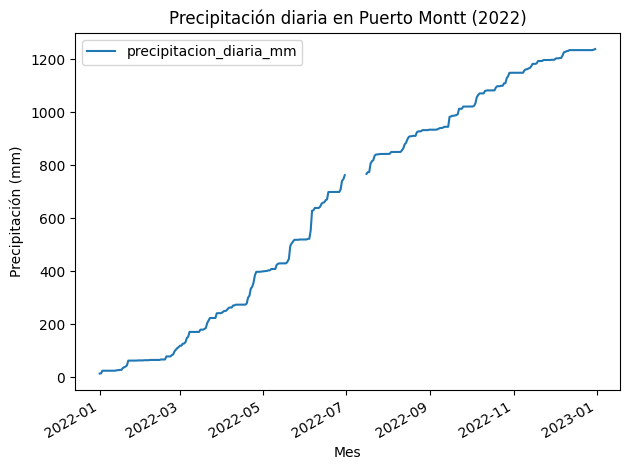

In [86]:
plt.figure(figsize=(15,6))
data_to_plot = PMontt.loc["2022"].cumsum()
ax = data_to_plot.plot()
# Etiquetas
plt.xlabel("Mes")
plt.ylabel("Precipitación (mm)")
plt.title("Precipitación diaria en Puerto Montt (2022)")
plt.tight_layout()
plt.show()

<p align="center">
  <img src="https://raw.githubusercontent.com/paulmunozpauta/Hidrology_Course/main/Static/Imgs/PMontt_estaciones_cercanas.png" width="800">
</p>

https://explorador.cr2.cl/

In [95]:
import pandas as pd
import numpy as np

def preparar_serie_precipitacion(df):
    df = df.copy()

    # limpiar nombres de columnas
    df.columns = df.columns.str.strip().str.lower()

    # renombrar por seguridad
    df = df.rename(columns={
        "agno": "anio",
        "año": "anio",
        "ano": "anio",
        "mes": "mes",
        "dia": "dia",
        "día": "dia",
        "valor": "precipitacion_diaria_mm",
        "precipitacion": "precipitacion_diaria_mm",
        "precipitación": "precipitacion_diaria_mm",
        "precipitacion_diaria": "precipitacion_diaria_mm"
    })

    # convertir columnas a numéricas
    for col in ["anio", "mes", "dia", "precipitacion_diaria_mm"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # eliminar filas con datos faltantes en columnas clave
    df = df.dropna(subset=["anio", "mes", "dia", "precipitacion_diaria_mm"])

    # convertir año, mes y día a enteros
    df["anio"] = df["anio"].astype(int)
    df["mes"] = df["mes"].astype(int)
    df["dia"] = df["dia"].astype(int)

    # crear columna fecha
    df["fecha"] = pd.to_datetime(
        dict(year=df["anio"], month=df["mes"], day=df["dia"]),
        errors="coerce"
    )

    # eliminar fechas inválidas
    df = df.dropna(subset=["fecha"])

    # dejar solo serie temporal final
    df = df[["fecha", "precipitacion_diaria_mm"]].copy()

    # ordenar y usar fecha como índice
    df = df.sort_values("fecha").reset_index(drop=True)
    df = df.set_index("fecha")

    return df

In [96]:
LagoChapo_raw = pd.read_excel("LagoChapo_DGA_10430005.xlsx")
Puelo_raw = pd.read_excel("Puelo_DGA_10523001.xlsx")
Tepual_raw = pd.read_excel("Tepual_DMC_410005.xlsx")
Cascada_raw = pd.read_excel("Cascada_DGA_10410015.xlsx")

LagoChapo = preparar_serie_precipitacion(LagoChapo_raw)
Puelo = preparar_serie_precipitacion(Puelo_raw)
Tepual = preparar_serie_precipitacion(Tepual_raw)
Cascada = preparar_serie_precipitacion(Cascada_raw)

FileNotFoundError: [Errno 2] No such file or directory: 'LagoChapo_DGA_10430005.xlsx'